In [1]:
import pandas as pd

In [74]:
data=pd.read_excel(r"C:\Users\ADMIN\Desktop\final project\DATA SETS\ADHD_85pct_accuracy_dataset.xlsx")

In [75]:
data

,age,gender,inattention_score,hyperactivity_score,impulsivity_score,academic_performance,sleep_hours,screen_time_hours,family_history,teacher_complaints,emotional_regulation_score,anxiety_score,social_interaction_score,physical_activity_hours,diet_quality_score,ADHD
0,8,0,1.946584,2.106317,6.548601,8.592275,8.094775,3.413776,0.030494,2.597356,8.470668,2.782324,6.880916,7.896616,6.932142,0
1,18,0,7.793756,2.061126,7.253311,4.510088,NaN,9.601971,0.997404,2.776080,4.127379,4.480997,3.453211,3.561823,4.923785,1
2,8,0,2.281956,1.217477,1.690614,10.000000,9.634072,3.766066,0.000000,3.751262,9.249365,1.066485,7.393574,7.788989,4.869477,0
3,12,1,7.496658,1.687986,2.242887,8.337434,9.311922,8.713489,0.000000,2.213298,8.300653,1.310550,8.073335,2.117295,6.134397,0
4,7,0,0.415652,2.385712,1.716638,4.453816,7.200910,6.166058,0.025511,3.538335,3.400270,3.925479,4.326188,3.499518,5.653408,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,11,0,2.954379,6.305259,7.787299,4.553563,6.311846,8.639220,0.942941,0.225463,3.842707,5.746929,4.664994,5.579494,6.852900,0
996,10,0,3.516748,1.985762,3.775105,3.929945,6.960373,8.507211,0.910235,5.033057,4.556991,7.072691,3.649766,5.476222,7.914361,1
997,10,0,2.886838,2.189690,1.935520,7.574317,9.245160,0.721075,NaN,1.476751,9.998035,3.256851,4.145337,6.522349,6.201894,0
998,13,0,1.252421,1.268089,6.219000,6.150520,8.572670,0.357780,0.000000,2.013079,8.616997,0.494764,4.637965,4.687318,8.209208,1


In [76]:
data.sum

<bound method DataFrame.sum of      age  gender  inattention_score  hyperactivity_score  impulsivity_score  \
0      8       0           1.946584             2.106317           6.548601   
1     18       0           7.793756             2.061126           7.253311   
2      8       0           2.281956             1.217477           1.690614   
3     12       1           7.496658             1.687986           2.242887   
4      7       0           0.415652             2.385712           1.716638   
..   ...     ...                ...                  ...                ...   
995   11       0           2.954379             6.305259           7.787299   
996   10       0           3.516748             1.985762           3.775105   
997   10       0           2.886838             2.189690           1.935520   
998   13       0           1.252421             1.268089           6.219000   
999   14       0                NaN             4.042703           1.784328   

     academic_perfor

In [77]:
data_cleaned=data.drop_duplicates()

In [78]:
data.isnull().sum()

age                            0
gender                         0
inattention_score             64
hyperactivity_score            0
impulsivity_score              0
academic_performance          51
sleep_hours                   48
screen_time_hours             52
family_history                60
teacher_complaints            63
emotional_regulation_score     0
anxiety_score                 64
social_interaction_score       0
physical_activity_hours        0
diet_quality_score            43
ADHD                           0
dtype: int64

In [79]:
data.dropna(inplace=True)

In [80]:
data.isnull().sum()

age                           0
gender                        0
inattention_score             0
hyperactivity_score           0
impulsivity_score             0
academic_performance          0
sleep_hours                   0
screen_time_hours             0
family_history                0
teacher_complaints            0
emotional_regulation_score    0
anxiety_score                 0
social_interaction_score      0
physical_activity_hours       0
diet_quality_score            0
ADHD                          0
dtype: int64

In [81]:
data.columns

Index(['age', 'gender', 'inattention_score', 'hyperactivity_score',
       'impulsivity_score', 'academic_performance', 'sleep_hours',
       'screen_time_hours', 'family_history', 'teacher_complaints',
       'emotional_regulation_score', 'anxiety_score',
       'social_interaction_score', 'physical_activity_hours',
       'diet_quality_score', 'ADHD'],
      dtype='object')

In [82]:
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 8, 12, 18],
    labels=[0,1,2],
    include_lowest=True
)

In [83]:
data["total_symptom_score"] = (
    data["inattention_score"] +
    data["hyperactivity_score"] +
    data["impulsivity_score"]
)

In [84]:
data["lifestyle_risk_score"] = (
    0.3 * (8 - data["sleep_hours"]).clip(lower=0) +
    0.3 * data["screen_time_hours"] +
    0.2 * (3 - data["physical_activity_hours"]).clip(lower=0) +
    0.2 * (10 - data["diet_quality_score"])
)

In [85]:
data["academic_difficulty"] = (
    (100 - data["academic_performance"]) +
    data["teacher_complaints"]
)

In [86]:
data["emotional_dysregulation"] = (
    data["anxiety_score"] +
    (10 - data["emotional_regulation_score"])
)

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [88]:
data.columns

Index(['age', 'gender', 'inattention_score', 'hyperactivity_score',
       'impulsivity_score', 'academic_performance', 'sleep_hours',
       'screen_time_hours', 'family_history', 'teacher_complaints',
       'emotional_regulation_score', 'anxiety_score',
       'social_interaction_score', 'physical_activity_hours',
       'diet_quality_score', 'ADHD', 'age_group', 'total_symptom_score',
       'lifestyle_risk_score', 'academic_difficulty',
       'emotional_dysregulation'],
      dtype='object')

In [89]:
data.columns


Index(['age', 'gender', 'inattention_score', 'hyperactivity_score',
       'impulsivity_score', 'academic_performance', 'sleep_hours',
       'screen_time_hours', 'family_history', 'teacher_complaints',
       'emotional_regulation_score', 'anxiety_score',
       'social_interaction_score', 'physical_activity_hours',
       'diet_quality_score', 'ADHD', 'age_group', 'total_symptom_score',
       'lifestyle_risk_score', 'academic_difficulty',
       'emotional_dysregulation'],
      dtype='object')

In [101]:
x=[ 'total_symptom_score''lifestyle_risk_score''age_group'
       
       ]
y=['ADHD']

In [103]:
x= data.drop("ADHD", axis=1)
y = data["ADHD"]

In [104]:
print("x:", x.shape)
print("y:", y.shape)

x: (627, 20)
y: (627,)


In [105]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [106]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [107]:
y_pred=model.predict(x_test)

In [108]:
y_test

840    1
354    0
589    1
408    1
481    0
      ..
558    0
768    0
232    1
4      1
93     1
Name: ADHD, Length: 126, dtype: int64

In [109]:
from sklearn.metrics import accuracy_score

In [110]:
accuracy=accuracy_score(y_test,y_pred)

In [111]:
accuracy

0.8571428571428571

In [28]:
print("ADHD" in x.columns)

False


In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[84  5]
 [13 24]]


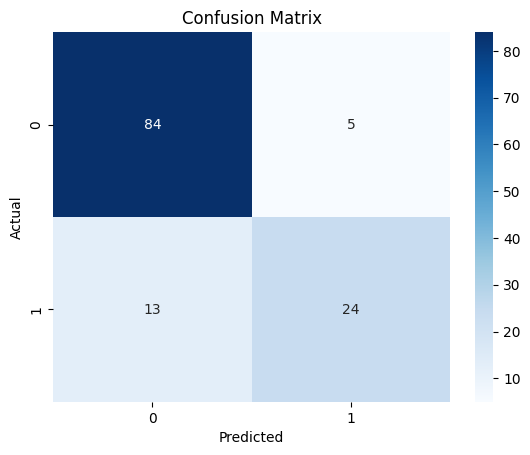

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [114]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8571428571428571
Precision: 0.8275862068965517
Recall: 0.6486486486486487
F1 Score: 0.7272727272727273


In [118]:
y_probs = model.predict_proba(x_test)[:, 1]

In [119]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

In [120]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_probs)
print("AUC:", auc_score)

AUC: 0.8097479501973885


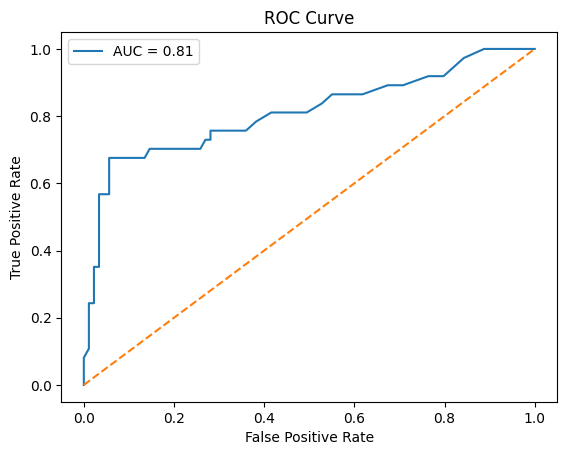

In [121]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()